<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#FFC300;font-family:sans-serif;color:#FFFFFF;font-size:250%;text-align:center;border-radius:15px 15px;">SMOKING SIGNAL OF BODY</p>

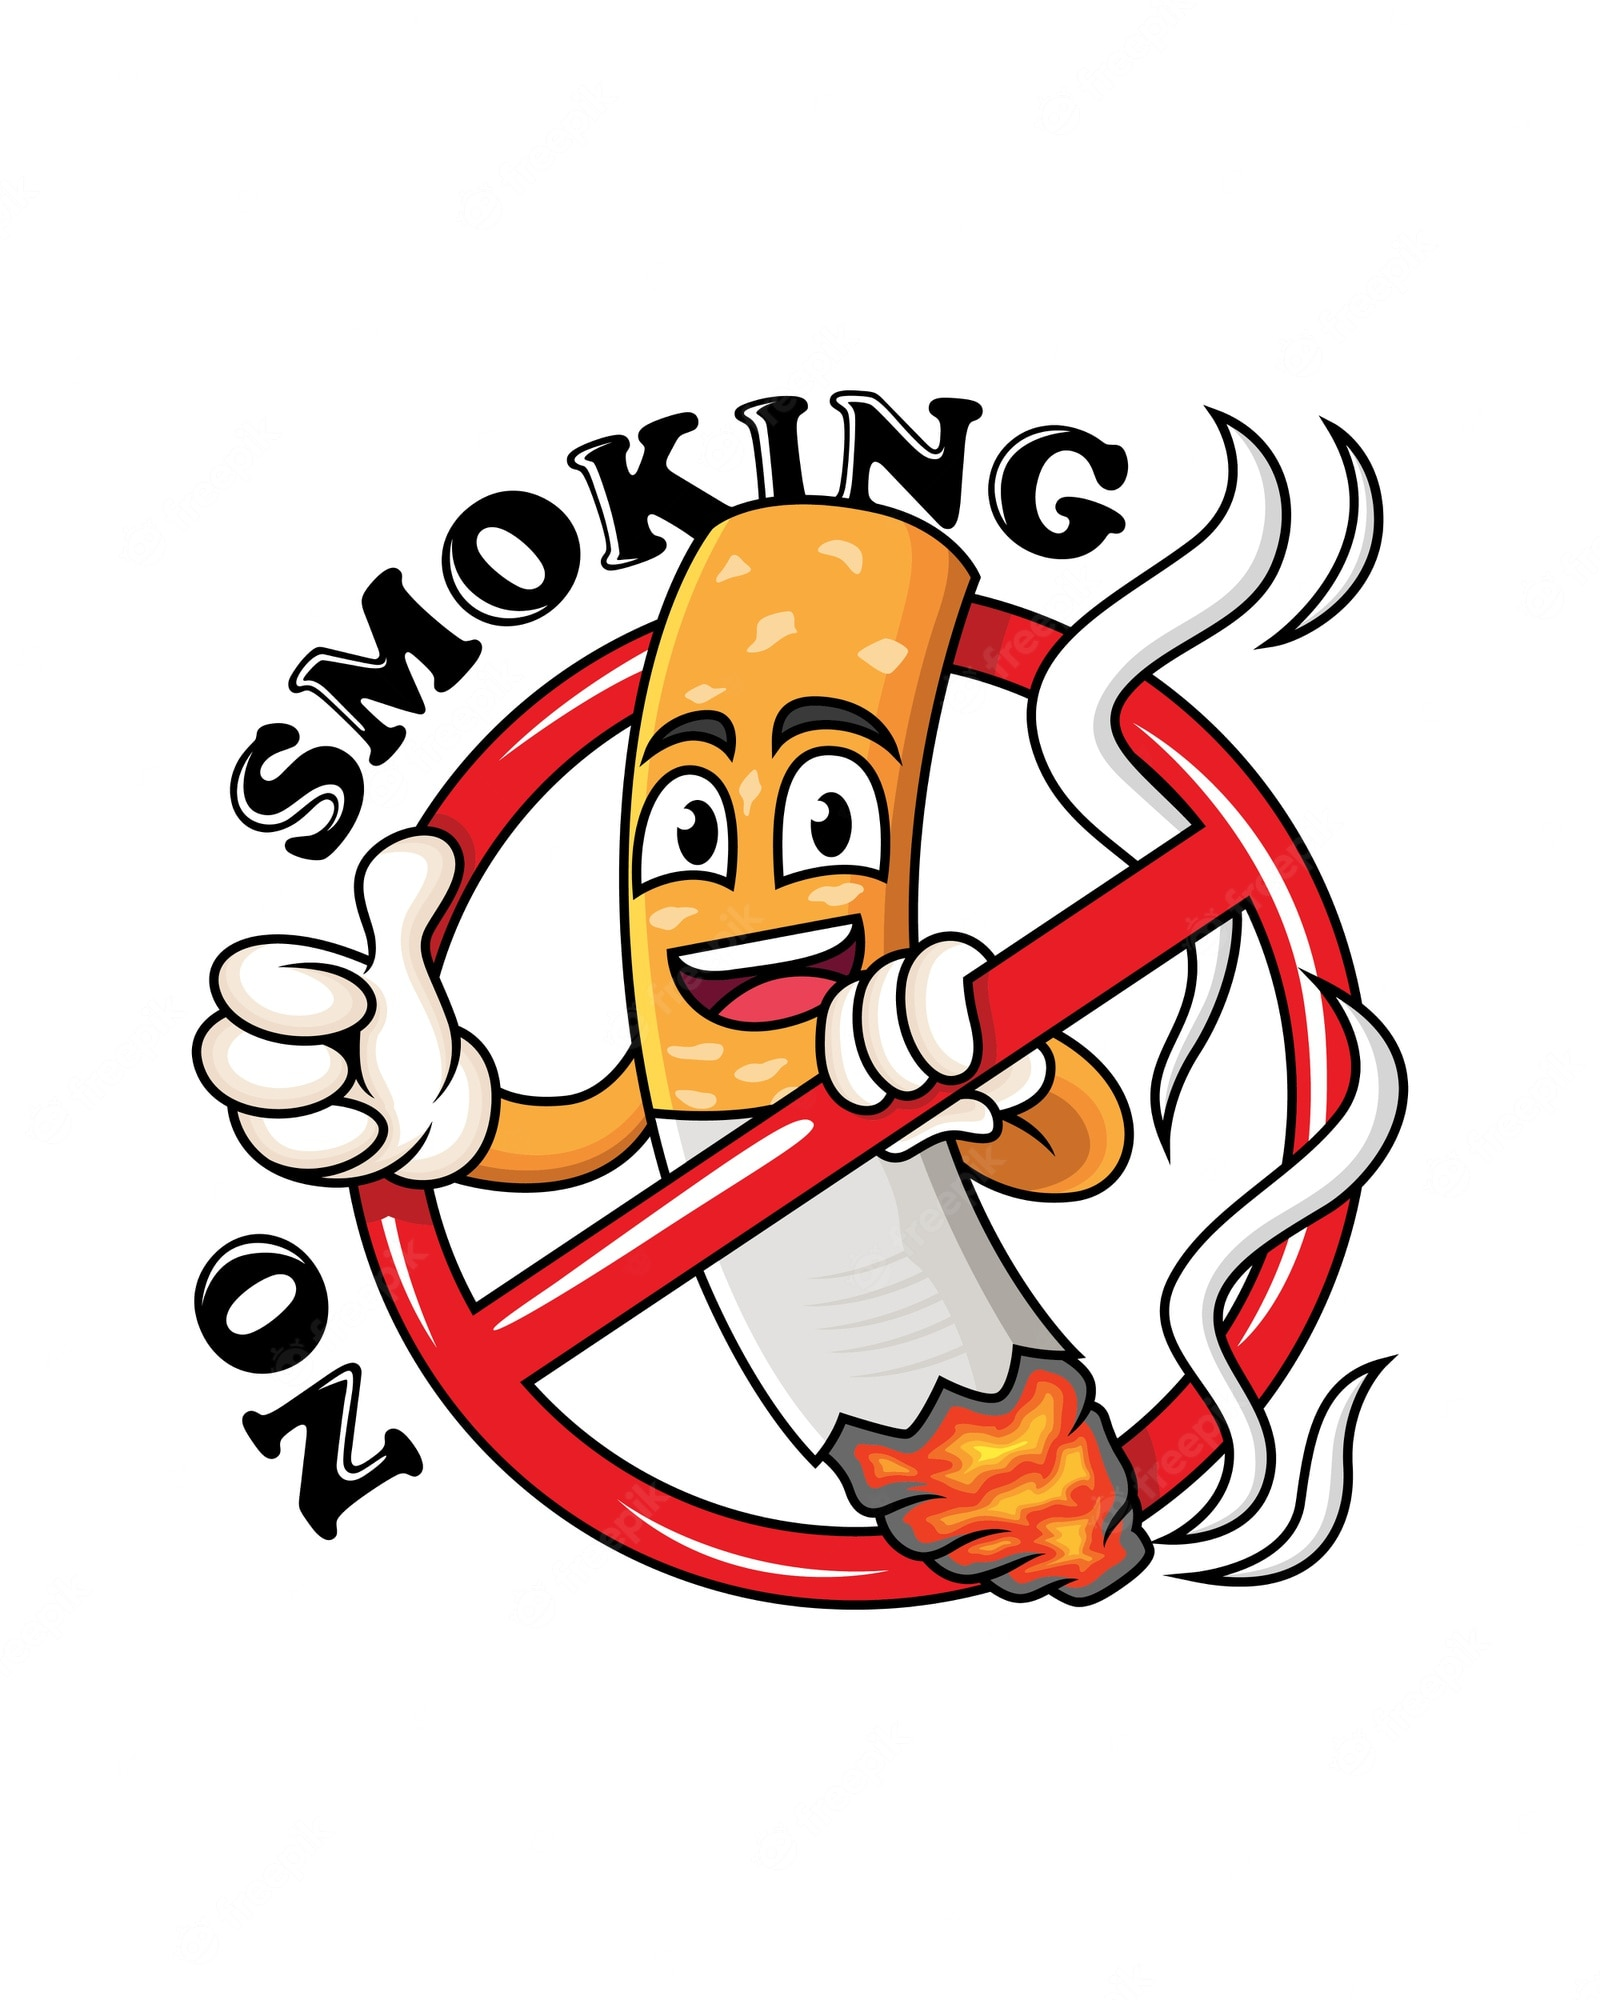

   <a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#ffc300;font-family:sans-serif;color:#FFF9ED;font-size:200%;text-align:center;border-radius:9px 9px;">TABLE OF CONTENTS</p>   
    
* [1. INTRODUCTION](#1)
    
* [2. IMPORT NECESSARY LIBRARIES](#2)
    
* [3. LOADING DATASET](#3)
    
* [4. INITIAL INFORMATION ABOUT DATASET](#4)
    
    * [4.1. Change Column Names](#4.1)    
    * [4.2. Basic Information About Dataset](#4.2)    
    * [4.3. Check null Values](#4.3)    
    * [4.4. Descriptive Statistics of Numeric Variables](#4.4)    
    
    
    
* [5. DATA VISUALIZATION](#5)
    
    * [5.1. Correlation and Heatmap](#5.1)    
    * [5.2. Pie Chart](#5.2)    
    * [5.3. Barplot](#5.3)    
    * [5.4. Catplot](#5.4)
    * [5.5. Pairplot](#5.5)
    * [5.6. Scatterplot](#5.6)
    * [5.7. Distplot](#5.7)
    * [5.8. Regplot](#5.8)
    * [5.9. 2D Histogram](#5.9)
    * [5.10. Pandas Crosstab](#5.10)
    * [5.11. Smooth Kernel Density With Marginal Histograms](#5.11)
    * [5.12. Visualization with Plotly Express](#5.12)
    
    
    
* [6. DATASET PREPROCESSİNG](#6)
    
    * [6.1. Look at Dataset and drop outliers](#6.1)    
    * [6.2. Encode Categoric Variables](#6.2)    
    * [6.3. Select Dependent and Independent Variables](#6.3)    
    * [6.4. Split the Dataset into Train and Test Sets](#6.4)
    * [6.5. Standardization process](#6.5)

    
    
* [7. BUİLDİNG CLASSİFİCATİON MODELS](#7)
    
    * [7.1. Random Forests Model](#7.1)    
    * [7.2. Get Accuracy Score of Random Forests Model on Test Set](#7.2)    
    * [7.3. Importance Level of Variables](#7.3)    
    * [7.4. Classification Report of Model](#7.4)
    * [7.5. ROC AUC](#7.5)
    * [7.6. Visualization Confusion Matrix](#7.6)
    * [7.7. XGBoost model and hyperparameter tuning](#7.7)
    * [7.8. Get accuracy score of XGB model on test set](#7.8)
    * [7.9. Comparison results with Pretty table](#7.9)
    * [7.10. Author's message](#7.10)

<a id="1"></a>

## <b>1 <span style='color:#4a8fdd'>|</span> INTRODUCTION</b>

<div style="border-radius:10px;
            border : black solid;
            background-color: 	#F5EBCB;
            font-size:120%;
            text-align: left">

<h3 style='; border:0; border-radius: 15px; font-weight: bold; color:black'><center>Means of the variables
</center></h3>  
    
This dataset is a collection of basic health biological signal data.    
The goal is to determine the presence or absence of smoking through bio-signals.

target variable:
NO smoking = 0, YES smoking = 1



<a id="2"></a>

## <b>2 <span style='color:#4a8fdd'>|</span> IMPORT NECESSARY LIBRARIES</b>

In [ ]:
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from sklearn.preprocessing import LabelEncoder # for encoding
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler #for standardization
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from termcolor import colored
import scipy.stats as st
from collections import Counter
%matplotlib inline

#!pip install pandas-profiling
#import pandas_profiling

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import plot_confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from mlxtend.classifier import StackingClassifier, StackingCVClassifier
!pip install prettytable
from prettytable import PrettyTable
# to ignore warnings
import warnings
warnings.filterwarnings("ignore")

#to see model hyperparameters
from sklearn import set_config
set_config(print_changed_only = False)

# to show all columns
pd.set_option('display.max_columns', 30)

print(colored("\nLIBRARIES WERE SUCCESFULLY IMPORTED...", color = "green", attrs = ["dark", "bold"]))

<a id="3"></a>

## <b>3 <span style='color:#4a8fdd'>|</span> LOADING DATASET</b>

In [ ]:
smoking = pd.read_csv("../input/body-signal-of-smoking/smoking.csv")
df = smoking.drop("ID", axis = 1)
df.head(n = 10).style.background_gradient(cmap = "Oranges")

<a id="4"></a>

## <b>4 <span style='color:#4a8fdd'>|</span> INITIAL INFORMATION ABOUT DATASET</b>

<a id="4.1"></a>

#### <b>4.1 <span style='color:#4a8fdd'>|</span> Change Column Names</b>

In [ ]:
df.rename(columns = {"height(cm)" : "height_cm", "weight(kg)" : "weight_kg",
                     "waist(cm)" : "waist_cm", "eyesight(left)" : "eyesight_left",
                     "eyesight(right)" : "eyesight_right", "hearing(left)" : "hearing_left",
                     "hearing(right)" : "hearing_right", "fasting blood sugar" : "fasting_blood_sugar",
                     "Cholesterol" : "cholesterol", "HDL" : "hdl", "LDL" : "ldl",
                     "Urine protein" : "urine_protein", "serum creatinine" : "serum_creatinine",
                     "AST" : "ast", "ALT" : "alt", "Gtp" : "gtp", "dental caries" : "dental_caries"},
          inplace = True)

print(colored("\nTHE COLUMNS OF DATASET WERE SUCCESFULLY RENAMED...", color = "green", attrs = ["dark", "bold"]))

<a id="4.2"></a>

#### <b>4.2 <span style='color:#4a8fdd'>|</span> Basic information about the dataset</b>

In [ ]:
df.info()

<a id="4.3"></a>

#### <b>4.3 <span style='color:#4a8fdd'>|</span> Check null Values</b>

In [ ]:
print("\nThere are totally {} null values in the dataset".format(df.isnull().sum().sum()))

<div style="border-radius:10px;
            border : black solid;
            background-color: 	#F5EBCB;
            font-size:120%;
            text-align: left">

<h4 style='; border:0; border-radius: 15px; font-weight: bold; color:black'><center>Brief information</center></h4>  
    

Here we see that there are 27 (ID variable including) columns and 55692 rows in this dataset. Of the variables' data types, 18 are float, 5 are integer and 3 are object. Memory usage of this dataset: 11 MB. There is not any null value in dataset

<a id="4.4"></a>

#### <b>4.4 <span style='color:#4a8fdd'>|</span> Descriptive Statistics of Numeric Variables</b>

In [ ]:
df.describe().T.style.background_gradient(cmap = "coolwarm_r")

<a id="5"></a>

## <b>5 <span style='color:#4a8fdd'>|</span> DATA VISUALIZATION</b>

<a id="5.1"></a>

#### <b>5.1 <span style='color:#4a8fdd'>|</span> Correlation and Heatmap</b>

In [ ]:
df.corr().style.background_gradient(cmap = "magma")

In [ ]:
plt.figure(figsize = [20, 10], clear = True, facecolor = "white")
sns.heatmap(df.corr(), annot = True, square = False, linewidths = 3,
            linecolor = "white", cmap = "Set2");

<a id="5.2"></a>

#### <b>5.2 <span style='color:#4a8fdd'>|</span> Pie Chart</b>

In [ ]:
plt.figure(figsize = [8, 8], clear = True, facecolor = "#ABB2B9")
df["smoking"].value_counts().plot.pie(explode = [0, 0.15], autopct='%1.3f%%', shadow = True);

In [ ]:
plt.figure(figsize = [8, 8], clear = True, facecolor = "#ABB2B9")
df["gender"].value_counts().plot.pie(explode = [0, 0.15], autopct='%1.2f%%', shadow = True);

<a id="5.3"></a>

#### <b>5.3 <span style='color:#4a8fdd'>|</span> Barplot</b>

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (12, 12))
axes = axes.flatten()

sns.barplot(ax = axes[0],
            x = df["gender"].value_counts().index,
            y = df["gender"].value_counts(),
            data = df, saturation = 1).set(title = "Frequency of classes of the 'gender' variable");

sns.barplot(ax = axes[1],
            x = df["tartar"].value_counts().index,
            y = df["tartar"].value_counts(),
            data = df, saturation = 1).set(title = "Frequency of cases of tartar");

sns.barplot(ax = axes[2],
            x = df["dental_caries"].value_counts().index,
            y = df["dental_caries"].value_counts(),
            data = df, saturation = 1).set(title = "Frequency of cases of dental caries");

sns.barplot(ax = axes[3],
            x = df["smoking"].value_counts().index,
            y = df["smoking"].value_counts(),
            data = df, saturation = 1).set(title = "Frequency of classes of the 'smoking' variable");

<a id="5.4"></a>

#### <b>5.4 <span style='color:#4a8fdd'>|</span> Catplot</b>

In [ ]:
sns.catplot(x = "gender",
            y = "cholesterol",
            kind = "box",
            hue = "smoking",
            color = '#F83419',
            data = df, saturation = 1, height = 7, aspect = 1.3,
            margin_titles = True).set(title = "cholesterol level by gender and smoking");

In [ ]:
sns.catplot(x = "gender",
            y = "weight_kg",
            hue = "smoking",
            kind = "boxen",
            color = '#B3EE22',
            data = df, saturation = 1, height = 7, aspect = 1.3,
            margin_titles = True).set(title = "weight by gender and smoking");

In [ ]:
sns.catplot(x = "gender",
            y = "age",
            hue = "smoking",
            kind = "boxen",
            color = '#468A85',
            data = df, saturation = 1, height = 7, aspect = 1.3,
            margin_titles = True).set(title = "age by gender (male and female) and smoking");

In [ ]:
sns.catplot(x = "gender",
            y = "relaxation",
            hue = "smoking",
            kind = "violin",
            color = '#FB2604',
            data = df, saturation = 1, height = 7, aspect = 1.35,
            margin_titles = True).set(title = "relaxation by gender and smoking");

In [ ]:
g = sns.catplot(x = "gender", y = "serum_creatinine", col = "smoking", 
                hue = "dental_caries",
                data = df,
                saturation = 1,
                kind = "bar",
                ci = "sd",
                aspect = 0.99)

(g.set_axis_labels("", "serum creatinine").set_xticklabels(["male", "female"])
  .set_titles("{col_name} {col_var}").despine(left = True));  

<a id="5.5"></a>

#### <b>5.5 <span style='color:#4a8fdd'>|</span> Pairplot</b>

In [ ]:
sns.pairplot(df, diag_kind = "hist", height = 4, aspect = 1, corner = True);

<a id="5.6"></a>

#### <b>5.6 <span style='color:#4a8fdd'>|</span> Scatterplot</b>

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (20, 12))
axes = axes.flatten()

sns.scatterplot(ax = axes[0], x = "weight_kg", y = "hemoglobin",
                hue = "smoking", size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'hemoglobin'");

sns.scatterplot(ax = axes[1], x = "weight_kg", y = "cholesterol", hue = "smoking",
                size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'cholesterol'");

sns.scatterplot(ax = axes[2], x = "weight_kg", y = "urine_protein", hue = "smoking",
                size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'urine_protein'");

sns.scatterplot(ax = axes[3], x = "weight_kg", y = "serum_creatinine", hue = "smoking",
                size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'serum_creatinine'");

sns.scatterplot(ax = axes[4], x = "weight_kg", y = "age", hue = "smoking",
                size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'age'");

sns.scatterplot(ax = axes[5], x = "weight_kg", y = "fasting_blood_sugar", hue = "smoking",
                size = "gender", sizes=(20, 100), legend="full",
                data = df).set(title = "Relationship between 'weight_kg' and 'fasting_blood_sugar'");

<a id="5.7"></a>

#### <b>5.7 <span style='color:#4a8fdd'>|</span> Distplot</b>

In [ ]:
df.hist(figsize = (20, 20), bins = 12, legend = False);

In [ ]:
sns.displot(
    data = df, x = "age", hue = "smoking",
    kind = "hist", height = 5, aspect = 1.5,
    palette="ch:rot=-.25,hue=1,light=.50").set(title =  "density relationship between 'age' and 'smoking' variables");


sns.displot(
    data = df, x = "systolic", hue = "smoking",
    kind = "kde", height = 5, aspect = 1.5,
    palette="ch:rot=-.25,hue=1,light=.50").set(title = "density relationship between 'systolic' and 'smoking' variables");


sns.displot(
    data = df, x = "waist_cm", hue = "smoking",
    kind = "kde", height = 5, aspect = 1.5, multiple="fill",
    palette="ch:rot=-.25,hue=1,light=.50").set(title = "density relationship between 'systolic' and 'smoking' variables");

<a id="5.8"></a>

#### <b>5.8 <span style='color:#4a8fdd'>|</span> Regplot</b>

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

sns.regplot(ax = axes[0], x = "age", y = "eyesight_left", data = df);
sns.regplot(ax = axes[1], x = "age", y = "eyesight_right", data = df);
sns.regplot(ax = axes[2], x = "age", y = "eyesight_right", data = df);
sns.regplot(ax = axes[3], x = "age", y = "hearing_left", data = df);
sns.regplot(ax = axes[4], x = "age", y = "relaxation", data = df);
sns.regplot(ax = axes[5], x = "age", y = "triglyceride", data = df);

<a id="5.9"></a>

#### <b>5.9 <span style='color:#4a8fdd'>|</span> 2D Histogram</b>

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (20, 5))

ax[0].hist2d(df["weight_kg"], df["systolic"])
ax[0].set_title("Relationship between 'weight_kg' and 'systolic' variables")

ax[1].hist2d(df["weight_kg"], df["hemoglobin"])
ax[1].set_title("Relationship between 'weight_kg' and 'hemoglobin' variables")

ax[2].hist2d(df["weight_kg"], df["smoking"])
ax[2].set_title("Relationship between 'weight_kg' and 'smoking' variables")

plt.show()

In [ ]:
sns.set_style("white")

fig, ax = plt.subplots(1, 3, figsize = (20, 5))

ax[0].hist2d(df["height_cm"], df["systolic"])
ax[0].set_title("Relationship between 'height_cm' and 'systolic' variables")

ax[1].hist2d(df["height_cm"], df["hemoglobin"])
ax[1].set_title("Relationship between 'height_cm' and 'hemoglobin' variables")

ax[2].hist2d(df["height_cm"], df["smoking"])
ax[2].set_title("Relationship between 'height_cm' and 'smoking' variables")
             
plt.show()

<a id="5.10"></a>

#### <b>5.10 <span style='color:#4a8fdd'>|</span> Pandas Crosstab</b>

In [ ]:
plt.style.use('fivethirtyeight')

pd.crosstab(df['gender'], df['smoking'],
            normalize = True).plot(kind = "pie", subplots = True, stacked=True);

In [ ]:
pd.crosstab(df['gender'], df['dental_caries'],
            normalize = True).plot(kind = "line", stacked=True);

In [ ]:
pd.crosstab(df['dental_caries'], df['smoking'],
            normalize = True).plot(kind = "area", stacked=True);

<a id="5.11"></a>

#### <b>5.11 <span style='color:#4a8fdd'>|</span>Smooth Kernel Density With Marginal Histograms</b>

In [ ]:
sns.set_theme(style = "whitegrid")

g = sns.JointGrid(data = df,
                  size = 7,
                  height = 5,
                  x = "age",
                  y = "hemoglobin",
                  space = 0.2)

g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "binary")
g.plot_marginals(sns.histplot, color = "#808080", alpha = 1, bins = 30);

In [ ]:
sns.set_theme(style = "dark")

g = sns.JointGrid(data = df,
                  size = 7,
                  height = 5,
                  x = "relaxation",
                  y = "cholesterol",
                  space = 0.2)

g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "bone")
g.plot_marginals(sns.histplot, color = "#808080", alpha = 1, bins = 30);

In [ ]:
g = sns.JointGrid(data = df,
                  size = 7,
                  height = 5,
                  x = "relaxation",
                  y = "systolic",
                  space = 0.4)

g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "bone_r")
g.plot_marginals(sns.histplot, color = "#808080", alpha = 1, bins = 30);

In [ ]:
g = sns.JointGrid(data = df,
                  size = 7,
                  height = 5,
                  x = "weight_kg",
                  y = "cholesterol",
                  space = 0.2)

g.plot_joint(sns.kdeplot, fill = False, thresh = 0, cmap = "winter")
g.plot_marginals(sns.histplot, color = "#808080", alpha = 1, bins = 30);

In [ ]:
g = sns.JointGrid(data = df,
                  size = 7,
                  height = 5,
                  x = "systolic",
                  y = "cholesterol",
                  space = 0.2)

g.plot_joint(sns.kdeplot, fill = False, thresh = 0, cmap = "afmhot")
g.plot_marginals(sns.histplot, fill = True, color = "#808080", alpha = 1, bins = 30);

<a id="5.12"></a>

#### <b>5.12 <span style='color:#4a8fdd'>|</span>Visualization with Plotly Express</b>

In [ ]:
fig = px.histogram(df, x = "age",
                   y = "cholesterol",
                   marginal = "box",
                   color = "smoking", hover_data  = df.columns)
fig.show()

In [ ]:
fig = px.histogram(df, x = "age",
                   y = "cholesterol",
                   marginal = "violin",
                   color = "gender", hover_data  = df.columns)
fig.show()

In [ ]:
fig = px.density_heatmap(df, x = "age", y = "hemoglobin", z = "cholesterol",
                        color_continuous_scale = "picnic", text_auto = True)
fig.show()

In [ ]:
fig = px.ecdf(df, x = "relaxation", log_x = True, log_y = True, color = "smoking", marginal = "histogram")
fig.show()

In [ ]:
fig = px.ecdf(df, x = "hemoglobin", log_x = True, log_y = True, color = "smoking", marginal = "histogram")
fig.show()

In [ ]:
fig = px.ecdf(df, x = "cholesterol", log_x = True, log_y = True, color = "smoking", marginal = "histogram")
fig.show()

In [ ]:
fig = px.ecdf(df, x = "cholesterol", log_x = True, log_y = True, color = "gender", marginal = "histogram")
fig.show()

In [ ]:
fig = px.scatter_3d(df, 
                    x = "hemoglobin",
                    y = "age",
                    z = "cholesterol",
                    color="smoking")
fig.show();

<a id="6"></a>

## <b>6 <span style='color:#4a8fdd'>|</span> DATASET PREPROCESSING</b>

<a id="6.1"></a>

#### <b>6.1 <span style='color:#4a8fdd'>|</span>Look at dataset and drop outliers</b>

In [ ]:
df.head(n = 10).style.background_gradient(cmap = "Oranges")

In [ ]:
def outlier_detection(df, n, columns):
    rows = []
    will_drop_train = []
    for col in columns:
        Q1 = np.nanpercentile(df[col], 25)
        Q3 = np.nanpercentile(df[col], 75)
        IQR = Q3 - Q1
        outlier_point = 1.5 * IQR
        rows.extend(df[(df[col] < Q1 - outlier_point)|(df[col] > Q3 + outlier_point)].index)
    for r, c in Counter(rows).items():
        if c >= n: will_drop_train.append(r)
    return will_drop_train

will_drop_train = outlier_detection(df, 5, df.select_dtypes(["float", "int"]).columns)
will_drop_train[0:5]

In [ ]:
df.drop(will_drop_train, inplace = True, axis = 0)

<a id="6.2"></a>

#### <b>6.2 <span style='color:#4a8fdd'>|</span> Encode Categoric Variables</b>

In [ ]:
lbe = LabelEncoder()
lbe.fit_transform(df["gender"])
df["gender"] = lbe.fit_transform(df["gender"])

In [ ]:
lbe = LabelEncoder()
lbe.fit_transform(df["tartar"])
df["tartar"] = lbe.fit_transform(df["tartar"])

In [ ]:
lbe = LabelEncoder()
lbe.fit_transform(df["oral"])
df["oral"] = lbe.fit_transform(df["oral"])

<a id="6.3"></a>

#### <b>6.3 <span style='color:#4a8fdd'>|</span>Select Dependent (label) and Independent (estimator) Variables</b>

In [ ]:
# select dependent variable (label)
y = df["smoking"]

# select independent variable (estimator)
x = df.drop("smoking", axis = 1)

<a id="6.4"></a>

#### <b>6.4 <span style='color:#4a8fdd'>|</span> Split the Dataset into Train and Test Sets</b>

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.10,
                                                    shuffle = True,
                                                    random_state = 1)

<a id="6.5"></a>

#### <b>6.5 <span style='color:#4a8fdd'>|</span> Standardization process</b>

In [ ]:
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

<a id="7"></a>

## <b>7<span style='color:#4a8fdd'>|</span> BUILDING CLASSIFICATION MODELS</b>

> <a id="7.1"></a>

#### <b>7.1<span style='color:#4a8fdd'>|</span> Random Forest model</b>

In [ ]:
rf_model = RandomForestClassifier(n_estimators = 2000)
rf_model.fit(x_train, y_train)

> <a id="7.2"></a>

#### <b>7.2<span style='color:#4a8fdd'>|</span> Get Accuracy Score on Test Set</b>

In [ ]:
y_pred = rf_model.predict(x_test)
accuracy_score(y_test, y_pred)

> <a id="7.3"></a>

#### <b>7.3<span style='color:#4a8fdd'>|</span> Importance Level of Variables</b>

In [ ]:
importance = pd.DataFrame({"Importance": rf_model.feature_importances_ * 100},
                         index = pd.DataFrame(x_train).columns)
importance.sort_values(by = "Importance", axis = 0,
                       ascending = True).plot(kind = "bar", color = "red")
plt.xlabel("Importance levels of the variables")
plt.ylabel("Variables");

> <a id="7.4"></a>

#### <b>7.4<span style='color:#4a8fdd'>|</span> Classification Report of Model</b>

In [ ]:
print(classification_report(y_test, y_pred))

> <a id="7.5"></a>

#### <b>7.5<span style='color:#4a8fdd'>|</span> ROC AUC</b>

In [ ]:
rf_roc_auc = roc_auc_score(y_test, rf_model.predict(x_test))
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(x_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label = 'AUC (area = %0.2f)' % rf_roc_auc)
plt.plot([0, 1], [0, 1],'g--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()

> <a id="7.6"></a>

#### <b>7.6<span style='color:#4a8fdd'>|</span> Visualization Confusion Matrix</b>

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred)
print(conf_mat)

sns.heatmap(conf_mat, square = True, annot = True, robust = True)
plt.show()

In [ ]:
plot_confusion_matrix(rf_model, x_test, y_test, cmap = plt.cm.Greens, normalize = "true");

> <a id="7.7"></a>

#### <b>7.7<span style='color:#4a8fdd'>|</span> XGBoost model</b>

In [ ]:
xgb_model = XGBClassifier(n_estimators = 2000)
xgb_model.fit(x_train, y_train)

> <a id="7.8"></a>

#### <b>7.8<span style='color:#4a8fdd'>|</span> Get accuracy score of XGBoost model on test set</b>

In [ ]:
y_pred = xgb_model.predict(x_test)
accuracy_score(y_test, y_pred)

> <a id="7.9"></a>

#### <b>7.9<span style='color:#4a8fdd'>|</span> Comparison results with Pretty table</b>

In [ ]:
x = PrettyTable()
print('\n')
print("Comparison of XGBoost and Random Forest Results")
x.field_names = ["Model", "Accuracy"]

x.add_row(["XGBoost model", round(accuracy_score(y_test, xgb_model.predict(x_test)), 2)])
x.add_row(["Random Forest model", round(accuracy_score(y_test, rf_model.predict(x_test)), 3)])

print(x)
print('\n')

> <a id="7.10"></a>

#### <b>7.10<span style='color:#4a8fdd'>|</span> Author's message</b>

# Thank you all 🙂